In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm, trange

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

import torch

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

/data/xujs/miniconda3/lib/python3.7/site-packages/sklearn/utils/validation.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LARGE_SPARSE_SUPPORTED = LooseVersion(scipy_version) >= '0.14.0'
/data/xujs/miniconda3/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eps=np.finfo(np.float).eps,
/data/xujs/miniconda3/lib/python3.7/site-packages/sklearn/linear_model/least_angle.py:597: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is 

In [ ]:
# ## K562 subcompartment
# df_K562_subcompartment_100k = pd.read_table('SNIPER_K562_Subcompartment_annotation.csv', sep=',', header=0)
# prob = df_K562_subcompartment_100k.iloc[:, 3:].to_numpy()
# label_idx = np.argmax(prob, axis=1)
# label_dict = {0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'B3'}
# label = np.array([label_dict[idx] for idx in label_idx])

# df_K562_subcompartment_100k['Label'] = label
# df_K562_subcompartment_100k[['chrom', 'start', 'end', 'Label']].to_csv('./liftOver_hg19_to_hg38/SNIPER_K562_Subcompartment_annotation.hg19.bed', sep='\t', header=False, index=False)

In [2]:
df_hg38_GM12878_subcompartment_100kb = pd.read_table('./liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.bed', sep='\t', header=None)
df_hg38_K562_subcompartment_100kb = pd.read_table('./liftOver_hg19_to_hg38/SNIPER_K562_Subcompartment_annotation.hg19_to_hg38.bed', sep='\t', header=None)

In [ ]:
bedtools intersect -a /data/xujs/References/human/hg38/hg38_windows/hg38.window_100kb.bed -b GSE63525_GM12878_subcompartments.hg19_to_hg38.bed -wa -wb -f 0.5 | awk -v OFS="\t" '{print $1,$2,$3,$7}' >GSE63525_GM12878_subcompartments.hg19_to_hg38.100kb.bed
bedtools intersect -a /data/xujs/References/human/hg38/hg38_windows/hg38.window_100kb.bed -b SNIPER_K562_Subcompartment_annotation.hg19_to_hg38.bed -wa -wb -f 0.5 | awk -v OFS="\t" '{print $1,$2,$3,$7}' >SNIPER_K562_Subcompartments.hg19_to_hg38.100kb.bed

In [3]:
## 100kb subcompartment
df_hg38_100kb = pd.read_table('/data/xujs/References/human/hg38/hg38_windows/hg38.window_100kb.bed', header=None)
df_hg38_100kb.columns = ['chrom', 'start', 'end']
df_hg38_100kb = df_hg38_100kb.loc[~df_hg38_100kb.chrom.isin(["chrX", "chrY", "chrM"])]

## GM12878
df_hg38_GM12878_subcompartment_100kb = pd.read_table('./liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.100kb.bed', header=None)
df_hg38_GM12878_subcompartment_100kb.columns = ['chrom', 'start', 'end', 'label']
df_hg38_GM12878_subcompartment_100kb = pd.merge(df_hg38_100kb, df_hg38_GM12878_subcompartment_100kb, how='outer')
df_hg38_GM12878_subcompartment_100kb.fillna('X', inplace=True)

## K562
df_hg38_K562_subcompartment_100kb = pd.read_table('./liftOver_hg19_to_hg38/SNIPER_K562_Subcompartments.hg19_to_hg38.100kb.bed', header=None)
df_hg38_K562_subcompartment_100kb.columns = ['chrom', 'start', 'end', 'label']
df_hg38_K562_subcompartment_100kb = pd.merge(df_hg38_100kb, df_hg38_K562_subcompartment_100kb, how='outer')
df_hg38_K562_subcompartment_100kb.fillna('X', inplace=True)

In [4]:
df_hg38_100kb = pd.read_table('/data/xujs/References/human/hg38/hg38_windows/hg38.window_100kb.bed', header=None)
df_hg38_100kb.columns = ['chrom', 'start', 'end']
df_hg38_100kb = df_hg38_100kb.loc[~df_hg38_100kb.chrom.isin(["chrX", "chrY", "chrM"])]

df_hg38_GM12878_subcompartment_100kb = pd.read_table('./liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.100kb.bed', header=None)
df_hg38_GM12878_subcompartment_100kb.columns = ['chrom', 'start', 'end', 'label']
df_hg38_GM12878_subcompartment_100kb = pd.merge(df_hg38_100kb, df_hg38_GM12878_subcompartment_100kb, how='outer')
df_hg38_GM12878_subcompartment_100kb.fillna('X', inplace=True)
df_hg38_GM12878_subcompartment_100kb = df_hg38_GM12878_subcompartment_100kb.groupby(['chrom', 'start', 'end'], as_index=False).first()

In [6]:
## 1Mb subcompartment
df_hg38_1Mb = pd.read_table('/data/xujs/References/human/hg38/hg38_windows/hg38.window_1Mb.bed', header=None)
df_hg38_1Mb.columns = ['chrom', 'start', 'end']
df_hg38_1Mb = df_hg38_1Mb.loc[~df_hg38_1Mb.chrom.isin(["chrX", "chrY", "chrM"])]

def get_region_label(tmp_label):
    """
    统计1Mb区间内100kb下label的数量: A1, A2, A3, B1, B2, X
    """
    label_num = Counter(tmp_label)

    # When more than half of the labels belong to the same group, that 1-Mb bin is labeled as the corresponding subcompartment.
    res = [k for k,v in label_num.items() if v>5]

    label = [res[0] if len(res) else 'X']

    return label[0]

## GM12878 1Mb subcompartment label
df_hg38_GM12878_subcompartment_1Mb = df_hg38_1Mb.copy()
labels = []
for index, row in tqdm(df_hg38_GM12878_subcompartment_1Mb.iterrows()):
    tmp_label = df_hg38_GM12878_subcompartment_100kb.loc[(df_hg38_GM12878_subcompartment_100kb.chrom == row['chrom']) \
                                        & (df_hg38_GM12878_subcompartment_100kb.start >= row['start']) \
                                        & (df_hg38_GM12878_subcompartment_100kb.start < row['end']), 'label']
    labels.append(get_region_label(tmp_label))

df_hg38_GM12878_subcompartment_1Mb['label'] = labels


## K562 1Mb subcompartment label
df_hg38_K562_subcompartment_1Mb = df_hg38_1Mb.copy()
labels = []
for index, row in tqdm(df_hg38_K562_subcompartment_1Mb.iterrows()):
    tmp_label = df_hg38_K562_subcompartment_100kb.loc[(df_hg38_K562_subcompartment_100kb.chrom == row['chrom']) \
                                        & (df_hg38_K562_subcompartment_100kb.start >= row['start']) \
                                        & (df_hg38_K562_subcompartment_100kb.start < row['end']), 'label']
    labels.append(get_region_label(tmp_label))

df_hg38_K562_subcompartment_1Mb['label'] = labels

2887it [00:05, 497.58it/s]
2887it [00:04, 597.70it/s]


In [9]:
df_hg38_GM12878_subcompartment_1Mb.to_csv('/data/xujs/Project/HiC2PoreC/code/H2P/Analysis_Results/2024-05-06_embedding_visualization/liftOver_hg19_to_hg38/GSE63525_GM12878_subcompartments.hg19_to_hg38.1Mb.bed', sep='\t', header=None, index=False)
df_hg38_K562_subcompartment_1Mb.to_csv('/data/xujs/Project/HiC2PoreC/code/H2P/Analysis_Results/2024-05-06_embedding_visualization/liftOver_hg19_to_hg38/SNIPER_K562_Subcompartments.hg19_to_hg38.1Mb.bed', sep='\t', header=None, index=False)

In [5]:
node2chrom_1mb = pd.read_table('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.1000kb.node2chrom.txt', header=None, names=['node_id', 'chrom'])
node2chrom_100kb = pd.read_table('/data/xujs/Project/DeepLearning/MCIP/Results/preprocess_results/hg38.100kb.node2chrom.txt', header=None, names=['node_id', 'chrom'])

In [ ]:
def plot_emb_vis(emb, chroms, compartment_label, subcompartment_label, dataset):

    ## 设置color
    subcompartment_label_colors = {'A1': '#9b2025', 'A2': '#dea728', 'B1': '#a5a397', 'B2': '#7581cb', 'B3': '#7e6481', 'B4': '#3b8eea'}
    compartment_label_colors = {'A': '#e03322', 'B': '#30338e'}
    chrom_dict = {0: 'chr1', 1: 'chr2', 2: 'chr3', 3: 'chr4', 4: 'chr5', 5: 'chr6',
                6: 'chr7', 7: 'chr8', 8: 'chr9', 9: 'chr10', 10: 'chr11', 11: 'chr12',
                12: 'chr13', 13: 'chr14', 14: 'chr15', 15: 'chr16', 16: 'chr17', 17: 'chr18',
                18: 'chr19', 19: 'chr20', 20: 'chr21', 21: 'chr22', 22: 'chrX'}
    chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-3:]
    chrom_label_colors = {list(chrom_dict.values())[i]: chrom_label_colors[i] for i in range(len(chrom_dict))}

    ## 作图
    fig, axes = plt.subplots(3, 3, figsize=(6, 6), constrained_layout=True)
    axes = axes.flatten()

    alpha=0.7
    lw=0
    s=6

    ##  PCA
    vec = PCA(n_components=3).fit_transform(emb)
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=compartment_label, alpha=alpha, linewidth=lw, s=s, palette=compartment_label_colors, ax=axes[0])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=subcompartment_label, alpha=alpha, linewidth=lw, s=s, palette=subcompartment_label_colors, ax=axes[1])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=chroms, alpha=alpha, linewidth=lw, s=5, palette=chrom_label_colors, ax=axes[2])
    axes[0].set_title('PCA')
    axes[1].set_title('PCA')
    axes[2].set_title('PCA')
    axes[0].legend_.remove()
    axes[1].legend_.remove()
    axes[2].legend_.remove()

    ## UMAP
    vec = umap.UMAP().fit_transform(emb)
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=compartment_label, alpha=alpha, linewidth=lw, s=s, palette=compartment_label_colors, ax=axes[3])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=subcompartment_label, alpha=alpha, linewidth=lw, s=s, palette=subcompartment_label_colors, ax=axes[4])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=chroms, alpha=alpha, linewidth=lw, s=s, palette=chrom_label_colors, ax=axes[5])
    axes[3].set_title('UMAP')
    axes[4].set_title('UMAP')
    axes[5].set_title('UMAP')
    axes[3].legend_.remove()
    axes[4].legend_.remove()
    axes[5].legend_.remove()

    ## TSNE
    vec = TSNE().fit_transform(emb)
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=compartment_label, alpha=alpha, linewidth=lw, s=s, palette=compartment_label_colors, ax=axes[6])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=subcompartment_label, alpha=alpha, linewidth=lw, s=s, palette=subcompartment_label_colors, ax=axes[7])
    sns.scatterplot(x=vec[:,0], y=vec[:,1], hue=chroms, alpha=alpha, linewidth=lw, s=s, palette=chrom_label_colors, ax=axes[8])
    axes[6].set_title('TSNE')
    axes[7].set_title('TSNE')
    axes[8].set_title('TSNE')
    axes[6].legend_.remove()
    axes[7].legend_.remove()
    axes[8].legend_.remove()

    fig.suptitle(f'{dataset} Embedding visualization')
    # fig.savefig('HiPore-C_GM12878_1Mb_final_Embedding_visualization.pdf')
    return fig

In [1]:
### GM12878 1Mb Embedding.
test_chr = 'chr1'
dataset='HiPore-C_GM12878_1Mb'
embed_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/{dataset}/{dataset}_test_{test_chr}'

### 1. initial embedding
labels = df_hg38_GM12878_subcompartment_1Mb['label'].to_numpy()
emb = torch.load(f"/data/xujs/Project/HiC2PoreC/code/H2P/Emb/HiPore-C_GM12878_1Mb_64.pt", map_location=torch.device('cpu')).detach().cpu().numpy()
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[labels != 'X']
subcompartment_label = labels[labels != 'X']
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[labels != 'X']

fig = plot_emb_vis(emb, chroms, compartment_label, subcompartment_label, dataset)
fig.savefig(f'{dataset}_initial_Embedding_visualization.pdf')


### 2. final embedding
labels = df_hg38_GM12878_subcompartment_1Mb['label'].to_numpy()
emb = np.load(f'{embed_dir}/{dataset}_test_{test_chr}_ND_RNS_Struc_r0.trn_embeddings.npy', allow_pickle=True)
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[labels != 'X']
subcompartment_label = labels[labels != 'X']
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[labels != 'X']

fig = plot_emb_vis(emb, chroms, compartment_label, subcompartment_label, dataset)
fig.savefig(f'{dataset}_final_Embedding_visualization.pdf')

In [ ]:
### K562 1Mb Embedding.
dataset='HiPore-C_K562_1Mb'
test_chr = 'chr1'
embed_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/{dataset}/{dataset}_test_{test_chr}'

### 1. initial embedding
labels = df_hg38_K562_subcompartment_1Mb['label'].to_numpy()
emb = torch.load(f"/data/xujs/Project/HiC2PoreC/code/H2P/Emb/{dataset}_64.pt", map_location=torch.device('cpu')).detach().cpu().numpy()
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[labels != 'X']
subcompartment_label = labels[labels != 'X']
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[labels != 'X']

fig = plot_emb_vis(emb, chroms, compartment_label, subcompartment_label, dataset)
fig.savefig(f'{dataset}_initial_Embedding_visualization.pdf')


### 2. final embedding
labels = df_hg38_K562_subcompartment_1Mb['label'].to_numpy()
emb = np.load(f'{embed_dir}/{dataset}_test_{test_chr}_ND_BNS_Struc_r0.trn_embeddings.npy', allow_pickle=True)
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[labels != 'X']
subcompartment_label = labels[labels != 'X']
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[labels != 'X']

fig = plot_emb_vis(emb, chroms, compartment_label, subcompartment_label, dataset)
fig.savefig(f'{dataset}_final_Embedding_visualization.pdf')

In [125]:
### seaborn画带边缘分布的散点图

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
 
class SeabornFig2Grid():
 
    def __init__(self, seaborngrid, fig,  subplot_spec):
        self.fig = fig
        self.sg = seaborngrid
        self.subplot = subplot_spec
        if isinstance(self.sg, sns.axisgrid.FacetGrid) or \
            isinstance(self.sg, sns.axisgrid.PairGrid):
            self._movegrid()
        elif isinstance(self.sg, sns.axisgrid.JointGrid):
            self._movejointgrid()
        self._finalize()
 
    def _movegrid(self):
        """ Move PairGrid or Facetgrid """
        self._resize()
        n = self.sg.axes.shape[0]
        m = self.sg.axes.shape[1]
        self.subgrid = gridspec.GridSpecFromSubplotSpec(n,m, subplot_spec=self.subplot)
        for i in range(n):
            for j in range(m):
                self._moveaxes(self.sg.axes[i,j], self.subgrid[i,j])
 
    def _movejointgrid(self):
        """ Move Jointgrid """
        h= self.sg.ax_joint.get_position().height
        h2= self.sg.ax_marg_x.get_position().height
        r = int(np.round(h/h2))
        self._resize()
        self.subgrid = gridspec.GridSpecFromSubplotSpec(r+1,r+1, subplot_spec=self.subplot)
 
        self._moveaxes(self.sg.ax_joint, self.subgrid[1:, :-1])
        self._moveaxes(self.sg.ax_marg_x, self.subgrid[0, :-1])
        self._moveaxes(self.sg.ax_marg_y, self.subgrid[1:, -1])
 
    def _moveaxes(self, ax, gs):
        #https://stackoverflow.com/a/46906599/4124317
        ax.remove()
        ax.figure=self.fig
        self.fig.axes.append(ax)
        self.fig.add_axes(ax)
        ax._subplotspec = gs
        ax.set_position(gs.get_position(self.fig))
        ax.set_subplotspec(gs)
 
    def _finalize(self):
        plt.close(self.sg.fig)
        self.fig.canvas.mpl_connect("resize_event", self._resize)
        self.fig.canvas.draw()
 
    def _resize(self, evt=None):
        self.sg.fig.set_size_inches(self.fig.get_size_inches())

In [10]:
subcompartment_label_colors = {'A1': '#9b2025', 'A2': '#dea728', 'B1': '#a5a397', 'B2': '#7581cb', 'B3': '#7e6481', 'B4': '#3b8eea'}
compartment_label_colors = {'A': '#e03322', 'B': '#30338e'}
chrom_dict = {0: 'chr1', 1: 'chr2', 2: 'chr3', 3: 'chr4', 4: 'chr5', 5: 'chr6',
            6: 'chr7', 7: 'chr8', 8: 'chr9', 9: 'chr10', 10: 'chr11', 11: 'chr12',
            12: 'chr13', 13: 'chr14', 14: 'chr15', 15: 'chr16', 16: 'chr17', 17: 'chr18',
            18: 'chr19', 19: 'chr20', 20: 'chr21', 21: 'chr22', 22: 'chrX'}
chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-3:]
chrom_label_colors = {list(chrom_dict.values())[i]: chrom_label_colors[i] for i in range(len(chrom_dict))}


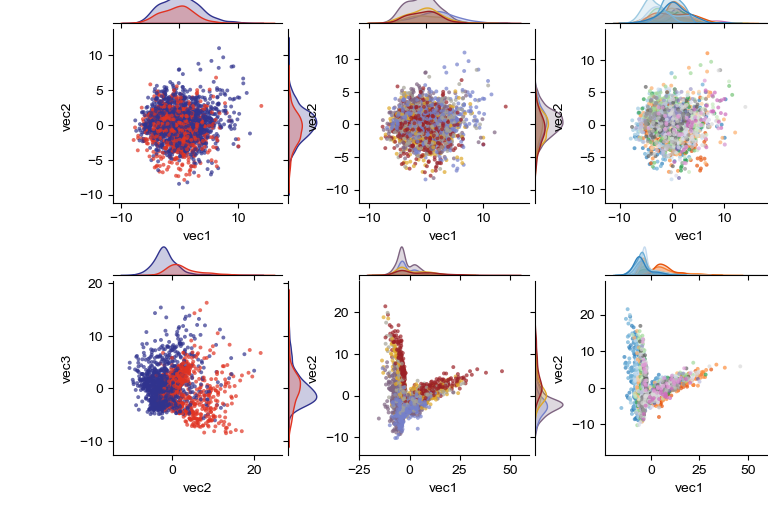

In [16]:
### 1. Initial embedding.
labels = df_hg38_GM12878_subcompartment_1Mb['label'].to_numpy()
emb = torch.load(f"/data/xujs/Project/HiC2PoreC/code/H2P/Emb/HiPore-C_GM12878_1Mb_64.pt", map_location=torch.device('cpu')).detach().cpu().numpy()
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label: label为X的舍弃
chroms = chroms[(labels != 'X') & (labels != 'B4')]
subcompartment_label = labels[(labels != 'X') & (labels != 'B4')]
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[(labels != 'X') & (labels != 'B4')]
vec = PCA(n_components=3).fit_transform(emb)

df_gm12878_1mb = pd.DataFrame({
    'vec1': vec[:, 0],
    'vec2': vec[:, 1],
    'vec3': vec[:, 2],
    'compartment': compartment_label,
    'subcompartment': subcompartment_label,
    'chrom': chroms
})

## 1.1. Compartment
compartment_label_colors = ['#e03322', '#30338e']
compartment_labels = ['A', 'B']
p0 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='compartment', hue_order=compartment_labels,
                palette=compartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 1.2. Subcompartment
subcompartment_label_colors = ['#9b2025', '#dea728', '#a5a397', '#7581cb', '#7e6481']
subcompartment_labels = ['A1', 'A2', 'B1', 'B2', 'B3']
p1 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='subcompartment', hue_order=subcompartment_labels,
                palette=subcompartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 1.3. Chromosome
chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-2:]
chrom_labels = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
                'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
                'chr21', 'chr22']
p2 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='chrom', hue_order=chrom_labels,
                palette=chrom_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)


### 2. Final embedding.
test_chr = 'chr5'
dataset='HiPore-C_GM12878_1Mb'
embed_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/{dataset}/{dataset}_test_{test_chr}'

labels = df_hg38_GM12878_subcompartment_1Mb['label'].to_numpy()
emb = np.load(f'{embed_dir}/{dataset}_test_{test_chr}_ND_RNS_Struc_r0.trn_embeddings.npy', allow_pickle=True)
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[(labels != 'X') & (labels != 'B4')]
subcompartment_label = labels[(labels != 'X') & (labels != 'B4')]
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[(labels != 'X') & (labels != 'B4')]
vec = PCA(n_components=3).fit_transform(emb)

df_gm12878_1mb = pd.DataFrame({
    'vec1': vec[:, 0],
    'vec2': vec[:, 1],
    'vec3': vec[:, 2],
    'compartment': compartment_label,
    'subcompartment': subcompartment_label,
    'chrom': chroms
})

## 2.1. Compartment
compartment_label_colors = ['#e03322', '#30338e']
compartment_labels = ['A', 'B']
p3 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='compartment', hue_order=compartment_labels,
                palette=compartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 2.2. Subcompartment
subcompartment_label_colors = ['#9b2025', '#dea728', '#a5a397', '#7581cb', '#7e6481']
subcompartment_labels = ['A1', 'A2', 'B1', 'B2', 'B3']
p4 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='subcompartment', hue_order=subcompartment_labels,
                palette=subcompartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 2.3. Chromosome
chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-2:]
chrom_labels = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
                'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
                'chr21', 'chr22']
p5 = sns.jointplot(data=df_gm12878_1mb, x='vec1', y='vec2',
                hue='chrom', hue_order=chrom_labels,
                palette=chrom_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(2, 3)
mp0 = SeabornFig2Grid(p0, fig, gs[0])
mp1 = SeabornFig2Grid(p1, fig, gs[1])
mp2 = SeabornFig2Grid(p2, fig, gs[2])
mp3 = SeabornFig2Grid(p3, fig, gs[3])
mp4 = SeabornFig2Grid(p4, fig, gs[4])
mp5 = SeabornFig2Grid(p5, fig, gs[5])
plt.show()
fig.savefig(f'./{dataset}_Embedding_PCA_visualization.pdf')

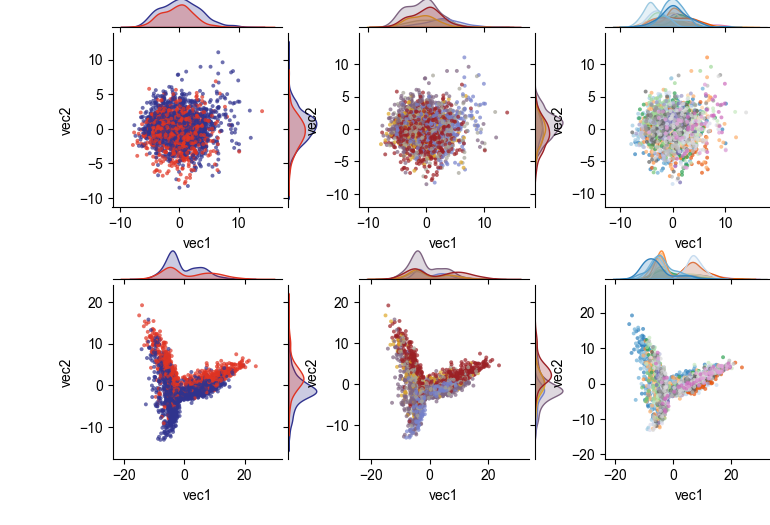

In [49]:
### 1. Initial embedding.
labels = df_hg38_K562_subcompartment_1Mb['label'].to_numpy()
emb = torch.load(f"/data/xujs/Project/HiC2PoreC/code/H2P/Emb/HiPore-C_K562_1Mb_64.pt", map_location=torch.device('cpu')).detach().cpu().numpy()
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label: label为X的舍弃
chroms = chroms[(labels != 'X') & (labels != 'B4')]
subcompartment_label = labels[(labels != 'X') & (labels != 'B4')]
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[(labels != 'X') & (labels != 'B4')]
vec = PCA(n_components=3).fit_transform(emb)

df_K562_1mb = pd.DataFrame({
    'vec1': vec[:, 0],
    'vec2': vec[:, 1],
    'compartment': compartment_label,
    'subcompartment': subcompartment_label,
    'chrom': chroms
})

## 1.1. Compartment
compartment_label_colors = ['#e03322', '#30338e']
compartment_labels = ['A', 'B']
p0 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='compartment', hue_order=compartment_labels,
                palette=compartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 1.2. Subcompartment
subcompartment_label_colors = ['#9b2025', '#dea728', '#a5a397', '#7581cb', '#7e6481']
subcompartment_labels = ['A1', 'A2', 'B1', 'B2', 'B3']
p1 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='subcompartment', hue_order=subcompartment_labels,
                palette=subcompartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 1.3. Chromosome
chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-2:]
chrom_labels = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
                'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
                'chr21', 'chr22']
p2 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='chrom', hue_order=chrom_labels,
                palette=chrom_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)


### 2. Final embedding.
test_chr = 'chr4'
dataset='HiPore-C_K562_1Mb'
embed_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/{dataset}/{dataset}_test_{test_chr}'

labels = df_hg38_K562_subcompartment_1Mb['label'].to_numpy()
emb = np.load(f'{embed_dir}/{dataset}_test_{test_chr}_ND_RNS_Struc_r0.trn_embeddings.npy', allow_pickle=True)
emb = emb[:labels.shape[0]]
chroms = node2chrom_1mb['chrom'].to_numpy()
chroms = chroms[chroms != 'chrX']

## 设置label; label为X的舍弃
chroms = chroms[(labels != 'X') & (labels != 'B4')]
subcompartment_label = labels[(labels != 'X') & (labels != 'B4')]
compartment_label = np.array(['A' if x in ['A1', 'A2'] else 'B' for x in subcompartment_label])
emb = emb[(labels != 'X') & (labels != 'B4')]
vec = PCA(n_components=3).fit_transform(emb)

df_K562_1mb = pd.DataFrame({
    'vec1': vec[:, 0],
    'vec2': vec[:, 1],
    'compartment': compartment_label,
    'subcompartment': subcompartment_label,
    'chrom': chroms
})

## 2.1. Compartment
compartment_label_colors = ['#e03322', '#30338e']
compartment_labels = ['A', 'B']
p3 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='compartment', hue_order=compartment_labels,
                palette=compartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 2.2. Subcompartment
subcompartment_label_colors = ['#9b2025', '#dea728', '#a5a397', '#7581cb', '#7e6481']
subcompartment_labels = ['A1', 'A2', 'B1', 'B2', 'B3']
p4 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='subcompartment', hue_order=subcompartment_labels,
                palette=subcompartment_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

## 2.3. Chromosome
chrom_label_colors = list(plt.get_cmap('tab20c').colors) + list(plt.get_cmap('tab20b').colors)[-2:]
chrom_labels = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
                'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
                'chr21', 'chr22']
p5 = sns.jointplot(data=df_K562_1mb, x='vec1', y='vec2',
                hue='chrom', hue_order=chrom_labels,
                palette=chrom_label_colors, legend=False,
                s=8, edgecolor='None', alpha=0.7, ratio=5, space=0.05)

fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(2, 3)
mp0 = SeabornFig2Grid(p0, fig, gs[0])
mp1 = SeabornFig2Grid(p1, fig, gs[1])
mp2 = SeabornFig2Grid(p2, fig, gs[2])
mp3 = SeabornFig2Grid(p3, fig, gs[3])
mp4 = SeabornFig2Grid(p4, fig, gs[4])
mp5 = SeabornFig2Grid(p5, fig, gs[5])
plt.show()
fig.savefig(f'./{dataset}_Embedding_PCA_visualization.pdf')